### Libraries.

In [1]:
from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
from sklearn.preprocessing import OneHotEncoder
import torch
from tqdm import tqdm

# from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Load Model.

In [2]:
PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/logs/2025-07-04_14-25-53/peach-vortex-14_FlowMatching.pkl"
flow_matching = FlowMatching.load(PATH)
flow_matching.trainer.plot_training_logs()


FileNotFoundError: [Errno 2] No such file or directory: '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/logs/2025-07-04_14-25-53/peach-vortex-14_FlowMatching.pkl'

### Generating some events.

In [ ]:
samples = flow_matching.predict(
    batch={},
    batch_size=400_000,
)


### Visualizing KDE of generated samples over each channel.

In [ ]:
adata = flow_matching.train_data
SUBSAMPLE_DONE = False
if not SUBSAMPLE_DONE:
    SUBSAMPLE_DONE = True
    sc.pp.subsample(adata, 0.01)
data = adata.state_data

int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}

if isinstance(weights, torch.Tensor):
    weights = weights.squeeze().detach().cpu().numpy()    # shape (5,)
    means = means.detach().cpu().numpy()                  # shape (5, 21)
    covs = covs.squeeze().detach().cpu().numpy()          # shape (5,)
weight = special.softmax(weights) 
covs = special.softplus(covs) 
# stds = np.sqrt(covs)[:, None]          # shape (5, 1)

# Your data: shape (N, 21)
# data = torch.randn(1000, 21).numpy()
data = adata.obsm[key_arcsin]
data = data

dims = means.shape[1]  # 21

fig, axs = plt.subplots(7, 3, figsize=(18, 22))
axs = axs.flatten()

for dim in range(dims):
    ax = axs[dim]

    # Define linspace over the data range for this dimension
    data_min = data[:, dim].min()
    data_max = data[:, dim].max()
    padding = 0.1 * (data_max - data_min)
    x_grid = np.linspace(data_min - padding, data_max + padding, 100)

    # KDE from data
    sns.kdeplot(data[:, dim], ax=ax, label='KDE', color='black')


### Defining function to visualize generated samples.

In [5]:
def concatenate_adata_and_plot(
    adata, samples, plot_pcs=True, plot_umap=True, subsample_size=0.1, coloring=["dataset_type"], key="X_pca", **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(adata.shape[0])] + ["Generated" for _ in range(samples.shape[0])], **kwargs}
    adata_generated = AnnData(X=np.concatenate([adata.obsm[key], samples], axis=0), obs=obs)
    adata_generated.obsm[key] = adata_generated.X.copy()

    if plot_umap:
        sc.pp.subsample(adata_generated, subsample_size)
        sc.pp.neighbors(adata_generated)
        sc.tl.umap(adata_generated)
        
    for color in coloring:
        if plot_pcs:
            sc.pl.embedding(adata_generated, basis=key, color=color)
        if plot_umap:
            sc.pl.umap(adata_generated, color=color)
    return adata_generated


### Visualizing the generated samples.


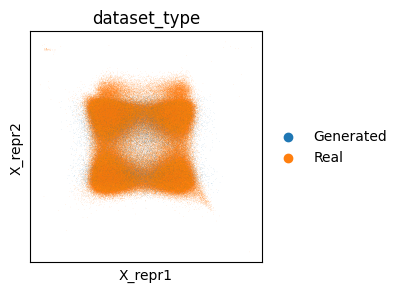

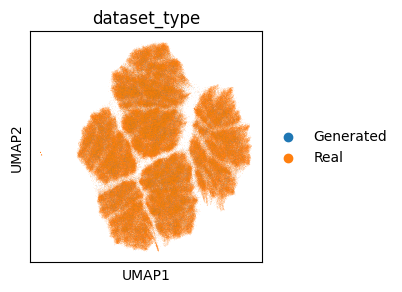

In [8]:
adata_generated = concatenate_adata_and_plot(
    sc.pp.subsample(flow_matching.train_data.adata, 0.1, copy=True),
    samples.cpu().numpy(),
    key=flow_matching.data_manager.sample_rep
)
